---
<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
        Dinámica del clima   
  </span>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:Blue; font-size:160%;">Unidad 2:Sistemas monzónicos</span><br/>
  <span style="color:Blue; font-size:140%;">Facultad de Ciencias  |  Semestre 2027-I</span><br/>
</p>

---

# **<font color="Navy">  Variabilidad Interanual Climática</font>**
---
---

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

La variable de interés es la altura geopotencial en 500 hPa. Para ello, se deben obtener los datos de la ERA5 (que tiene resolución temporal horaria o diaria) y calcular la STD de las anomalías en cada punto de la cuadrícula. Para reproducir las bandas exactas de la figura (T > 30 días, 7 < T < 30 días, y T < 7 días), es necesario aplicar filtros de paso bajo y paso alto.

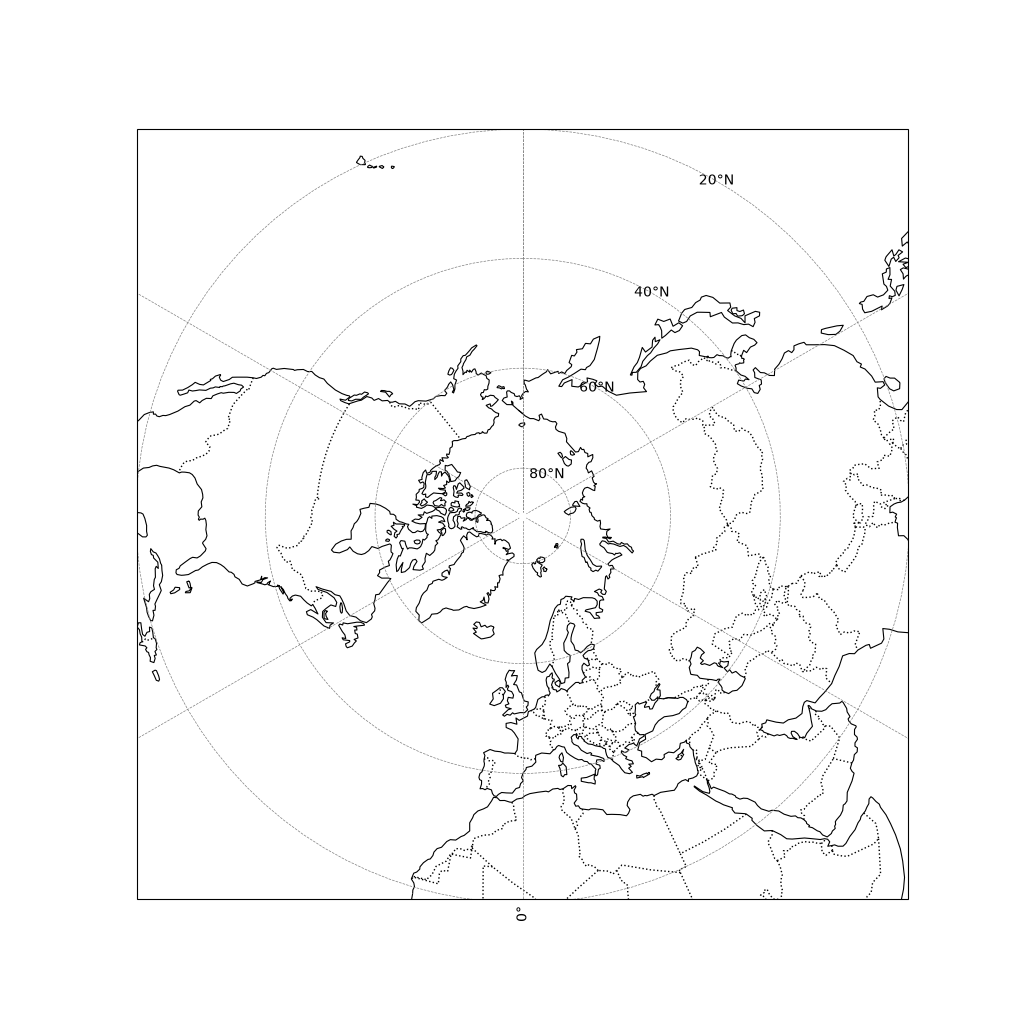

In [ ]:

# Configuramos la figura y la proyección
fig = plt.figure(figsize=(10, 10))
projection = ccrs.NorthPolarStereo()
ax = plt.axes(projection=projection)

# Limitamos el área al hemisferio norte (20°N a 90°N)
ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())

# Añadir características geográficas (líneas de costa)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Configuramos las rejillas de latitud y longitud
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Simulamos el trazado de los datos
# lons y lats son las coordenadas, z_std es el cálculo de la desviación estándar
# ax.contourf(lons, lats, z_std, transform=ccrs.PlateCarree(), cmap='RdBu_r', levels=...)
# ax.contour(lons, lats, z_std, transform=ccrs.PlateCarree(), colors='black', linewidths=0.5)

plt.title('Standard Deviation of 500 hPa Height (STD)')
plt.show()

In [20]:
# subimos los datos
ds_h = xr.open_dataset("hgt.mon.mean.nc")

print('Producto:', ds_h.attrs.get('title'))
print('Niveles (hPa):', ds_h.level.values)
print('Periodo completo:', str(ds_h.time.values[0])[:7], '->', str(ds_h.time.values[-1])[:7])

Producto: Monthly NCEP/DOE Reanalysis 2
Niveles (hPa): [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   70.   50.   30.   20.   10.]
Periodo completo: 1979-01 -> 2026-02


In [21]:
print(ds_h["time"].values)

['1979-01-01T00:00:00.000000000' '1979-02-01T00:00:00.000000000'
 '1979-03-01T00:00:00.000000000' '1979-04-01T00:00:00.000000000'
 '1979-05-01T00:00:00.000000000' '1979-06-01T00:00:00.000000000'
 '1979-07-01T00:00:00.000000000' '1979-08-01T00:00:00.000000000'
 '1979-09-01T00:00:00.000000000' '1979-10-01T00:00:00.000000000'
 '1979-11-01T00:00:00.000000000' '1979-12-01T00:00:00.000000000'
 '1980-01-01T00:00:00.000000000' '1980-02-01T00:00:00.000000000'
 '1980-03-01T00:00:00.000000000' '1980-04-01T00:00:00.000000000'
 '1980-05-01T00:00:00.000000000' '1980-06-01T00:00:00.000000000'
 '1980-07-01T00:00:00.000000000' '1980-08-01T00:00:00.000000000'
 '1980-09-01T00:00:00.000000000' '1980-10-01T00:00:00.000000000'
 '1980-11-01T00:00:00.000000000' '1980-12-01T00:00:00.000000000'
 '1981-01-01T00:00:00.000000000' '1981-02-01T00:00:00.000000000'
 '1981-03-01T00:00:00.000000000' '1981-04-01T00:00:00.000000000'
 '1981-05-01T00:00:00.000000000' '1981-06-01T00:00:00.000000000'
 '1981-07-01T00:00:00.000

In [23]:
# Región del Monzón de Norteamérica
LAT_S, LAT_N = 15, 35
LON_W, LON_E = 245, 260      # 115°O y 100°O en convención 0-360

# Periodo climatológico común a ambos datasets
YEAR_START, YEAR_END = 1991, 2020

MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
print(f'Región: {LAT_S}-{LAT_N}N, {360-LON_E}-{360-LON_W}O  (lon {LON_W}-{LON_E}E)')

Región: 15-35N, 100-115O  (lon 245-260E)


In [ ]:
# Recorte almismo periodo climatológico que la precipitación (1991-2020)

hgt = ds_h['hgt'].sel(time=slice(f'{YEAR_START}-01-01', f'{YEAR_END}-12-01'))

print('Pasos de tiempo usados:', hgt.sizes['time'], f'(= {hgt.sizes["time"]//12} años x 12 meses)')


Pasos de tiempo usados: 360 (= 30 años x 12 meses)


## <font color ="DarkBlue"> Climatología</font>

Obtener la Climatología: Se extraen los datos de altura geopotencial para los meses de invierno (Octubre a Marzo) y calcula la media de estos meses para cada punto de la cuadrícula.

In [25]:
# Climatología mensual
hgt_clim = hgt.groupby("time.month").mean(dim = "time")

Calcular Anomalías: Se hace la diferencia de la climatología a cada registro temporal (año por año)

In [ ]:
# Calcular anomalías: hgt real - climatología mensual

hgt_anom = hgt.groupby("time.month") - hgt_clim

Se hace la selección de los meses de invierno sobre las anomalías (tienen la dimensión de tiempo), y luego se calcula la desviación estándar.

In [27]:
# Seleccionar los meses de invierno de las anomalías
meses_invierno = [10, 11, 12, 1, 2, 3]

# La dimensión "time" está presente 
hgt_anom_invierno = hgt_anom.sel(time=hgt_anom.time.dt.month.isin(meses_invierno))

# Se calcula la desviación estándar para los meses de invierno
std_invierno = hgt_anom_invierno.std(dim="time")

# COmprobamos 'std_invierno' es la variable a graficar en el mapa polar
print(std_invierno.shape) # Debería ser (level, lat, lon)

(17, 73, 144)


In [30]:
# Seleccionamos el nivel 500
hgt_500 = hgt.sel(level=500)
hgt_500_anom = hgt_500.groupby("time.month") - hgt_500.groupby("time.month").mean(dim="time")
std_500 = hgt_500_anom.std(dim="time")

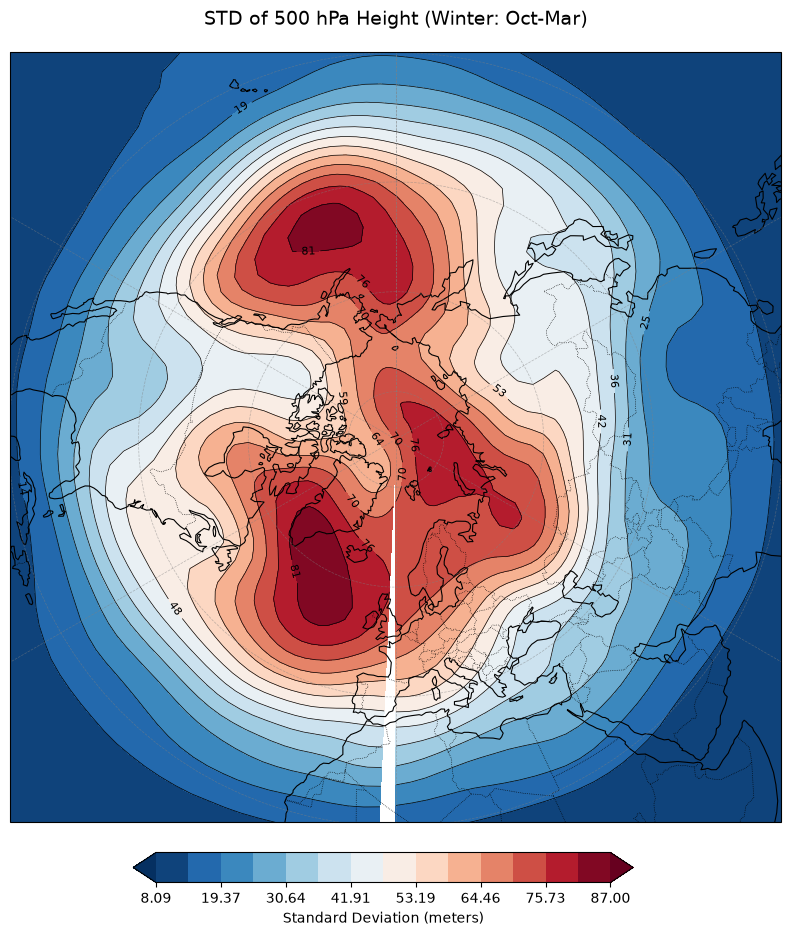

In [31]:
# Nivel de 500 hPa
std_500 = std_invierno.sel(level=500)

# Extraemos coordenadas y datos
lats = std_500.lat.values
lons = std_500.lon.values
data = std_500.values

fig = plt.figure(figsize=(10, 10))

# usamos la proyección Polar Estereográfica 
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)

# Limitamos el mapa al Hemisferio Norte (desde 20°N hasta el Polo)
ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())

levels = np.linspace(np.nanmin(data), np.nanmax(data), 15) 

cf = ax.contourf(lons, lats, data, 
                 levels=levels, 
                 transform=ccrs.PlateCarree(), 
                 cmap='RdBu_r', # Mapa de color Rojo-Azul invertido (como la figura)
                 extend='both')

cs = ax.contour(lons, lats, data, 
                levels=levels, 
                transform=ccrs.PlateCarree(), 
                colors='black', 
                linewidths=0.5)

ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f')

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
# Fronteras (opcional)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03]) # [izquierda, abajo, ancho, alto]
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Standard Deviation (meters)', fontsize=10)

ax.set_title('STD of 500 hPa Height (Winter: Oct-Mar)', fontsize=14, pad=20)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

plt.show()

Observamos que tenemos la desviación estándar de la altura geopotencial en 500 hPa. Aqui se mide cuánto se desvía la altura de ese nivel en un invierno dado respecto al promedio histórico de todos los inviernos (1991-2020). Notar que la altura del nivel de 500 hPa cambia mucho de un invierno a otro.

Además, la mancha roja superior sobre el Ártico/Norte de Canadá y Groenlandia indica que esta región está muy influenciada por el Vórtice Polar Estratosférico.En algunos inviernos, este vórtice es muy fuerte y frío (confinando el aire frío en el polo). En otros, sufre "calentamientos súbitos" (SSW) y se debilita, permitiendo que el aire frío se desplace hacia latitudes medias. Esta alternancia entre vórtice fuerte y débil genera una enorme variabilidad en la altura de 500 hPa.

Por otro lado, la mancho roja central sobre el Atlántico Norte y Europa indica la firma de la Oscilación del Atlántico Norte. La NAO es el principal modo de variabilidad climática en el Atlántico Norte. Cuando la NAO está en fase positiva, la corriente en chorro es fuerte y recta, mientras que cuando está en fase negativa, es débil y ondulada. Esta diferencia entre fases positivas y negativas es lo que genera esa gran desviación estándar.


## Referencias

- Hartmann, D. L. (2026). Global Physical Climatology (3rd ed.). Elsevier Science. ISBN: 978-0443273315.
